Input Data:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Target Output:
[[0.]
 [1.]
 [1.]
 [0.]]

Network Architecture:
2 Input Neurons
4 Hidden Neurons
1 Output Neuron

Initial Parameters:

W1:
[[ 0.24835708 -0.06913215  0.32384427  0.76151493]
 [-0.11707669 -0.11706848  0.78960641  0.38371736]]

b1:
[[0. 0. 0. 0.]]

W2:
[[-0.23473719]
 [ 0.27128002]
 [-0.23170885]
 [-0.23286488]]

b2:
[[0.]]

Initial Predictions:
[[0.44669943]
 [0.43029337]
 [0.42699871]
 [0.41263144]]

Initial Loss:
0.7045547507201497
Epoch: 0 Loss: 1.0508833348969482
Epoch: 1000 Loss: 0.0031588082185886996
Epoch: 2000 Loss: 0.0013458478175270379
Epoch: 3000 Loss: 0.0008518626407312902
Epoch: 4000 Loss: 0.0006223640519412782
Epoch: 5000 Loss: 0.0004899873220623377
Epoch: 6000 Loss: 0.0004039101893375602
Epoch: 7000 Loss: 0.00034348336108669375
Epoch: 8000 Loss: 0.00029874042777989205
Epoch: 9000 Loss: 0.0002642831213063026

FINAL RESULTS

Input:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Actual Output:
[[0.]
 [1.]
 [1.]
 [0.]]


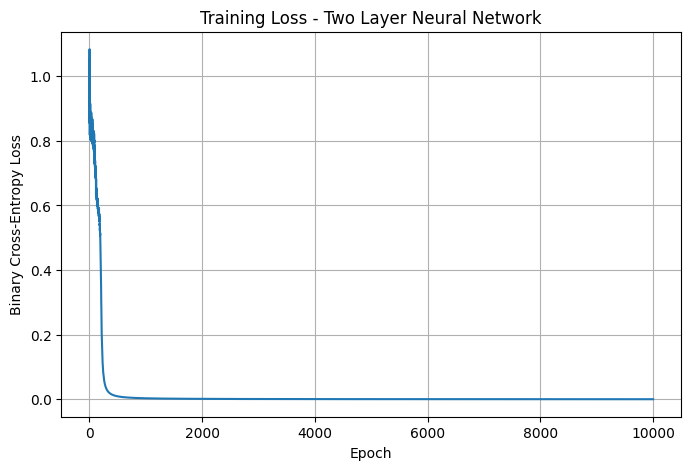


FINAL NETWORK PARAMETERS

Final W1:
[[-5.94952549 -6.79400165 -8.94164655  4.78708716]
 [-5.8608836  -6.69424672  4.93740641 -8.90601798]]

Final b1:
[[ 1.17409256  1.69747595 -1.23084609 -1.10570779]]

Final W2:
[[-5.9390352 ]
 [-7.74987089]
 [16.73597873]
 [16.73272324]]

Final b2:
[[-7.76661839]]

TRAINING SUMMARY
Architecture: 2 -> 4 -> 1
Learning Rate: 1.0
Epochs: 10000
Final Loss: 0.00023688638682761227
Final Accuracy: 100.0 %

The neural network has successfully learned XOR.


In [ ]:
# ============================================================
# ANN & DEEP LEARNING
# LAB 03: TWO-LAYER NEURAL NETWORK FROM SCRATCH
# Dataset: XOR
# Framework: NumPy
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE XOR DATASET
# ============================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Input Data:")
print(X)

print("\nTarget Output:")
print(y)


# ============================================================
# 2. DEFINE NETWORK ARCHITECTURE
# ============================================================

input_size = 2
hidden_size = 4
output_size = 1

print("\nNetwork Architecture:")
print(input_size, "Input Neurons")
print(hidden_size, "Hidden Neurons")
print(output_size, "Output Neuron")


# ============================================================
# 3. INITIALIZE WEIGHTS AND BIASES
# ============================================================

np.random.seed(42)

# Input Layer -> Hidden Layer
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

# Hidden Layer -> Output Layer
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("\nInitial Parameters:")

print("\nW1:")
print(W1)

print("\nb1:")
print(b1)

print("\nW2:")
print(W2)

print("\nb2:")
print(b2)


# ============================================================
# 4. SIGMOID ACTIVATION FUNCTION
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


# ============================================================
# 5. BINARY CROSS-ENTROPY LOSS
# ============================================================

def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-12

    # Avoid log(0)
    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_pred)
        +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss


# ============================================================
# 6. FORWARD PROPAGATION
# ============================================================

def forward_propagation(X, W1, b1, W2, b2):

    # -------------------------
    # Hidden Layer
    # -------------------------

    Z1 = np.dot(X, W1) + b1

    A1 = sigmoid(Z1)

    # -------------------------
    # Output Layer
    # -------------------------

    Z2 = np.dot(A1, W2) + b2

    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2


# ============================================================
# 7. CHECK INITIAL PREDICTIONS
# ============================================================

Z1, A1, Z2, A2 = forward_propagation(
    X,
    W1,
    b1,
    W2,
    b2
)

print("\nInitial Predictions:")
print(A2)

initial_loss = binary_cross_entropy(y, A2)

print("\nInitial Loss:")
print(initial_loss)


# ============================================================
# 8. TRAINING PARAMETERS
# ============================================================

learning_rate = 1.0
epochs = 10000

loss_history = []


# ============================================================
# 9. TRAINING USING SGD
# ============================================================

for epoch in range(epochs):

    # Shuffle training examples
    indices = np.random.permutation(len(X))

    epoch_loss = 0

    # --------------------------------------------------------
    # SGD: Update weights after EACH training example
    # --------------------------------------------------------

    for i in indices:

        # Select one training example
        X_sample = X[i:i+1]
        y_sample = y[i:i+1]

        # ====================================================
        # FORWARD PROPAGATION
        # ====================================================

        # Hidden layer
        Z1 = np.dot(X_sample, W1) + b1
        A1 = sigmoid(Z1)

        # Output layer
        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)


        # ====================================================
        # CALCULATE LOSS
        # ====================================================

        loss = binary_cross_entropy(
            y_sample,
            A2
        )

        epoch_loss += loss


        # ====================================================
        # BACKPROPAGATION
        # ====================================================

        # ----------------------------------------------------
        # Output Layer Gradients
        # ----------------------------------------------------

        dZ2 = A2 - y_sample

        dW2 = np.dot(
            A1.T,
            dZ2
        )

        db2 = dZ2


        # ----------------------------------------------------
        # Hidden Layer Gradients
        # ----------------------------------------------------

        dA1 = np.dot(
            dZ2,
            W2.T
        )

        # Derivative of sigmoid
        dZ1 = dA1 * A1 * (1 - A1)

        dW1 = np.dot(
            X_sample.T,
            dZ1
        )

        db1 = dZ1


        # ====================================================
        # SGD WEIGHT UPDATE
        # ====================================================

        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2

        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1


    # ========================================================
    # AVERAGE LOSS FOR THE EPOCH
    # ========================================================

    epoch_loss = epoch_loss / len(X)

    loss_history.append(epoch_loss)


    # Display progress
    if epoch % 1000 == 0:

        print(
            "Epoch:",
            epoch,
            "Loss:",
            epoch_loss
        )


# ============================================================
# 10. FINAL FORWARD PROPAGATION
# ============================================================

Z1, A1, Z2, predictions = forward_propagation(
    X,
    W1,
    b1,
    W2,
    b2
)


# ============================================================
# 11. DISPLAY FINAL PREDICTIONS
# ============================================================

print("\n====================================")
print("FINAL RESULTS")
print("====================================")

print("\nInput:")
print(X)

print("\nActual Output:")
print(y)

print("\nPredicted Probabilities:")
print(predictions)


# ============================================================
# 12. CONVERT PROBABILITIES TO 0 OR 1
# ============================================================

predicted_classes = (
    predictions >= 0.5
).astype(int)

print("\nPredicted Classes:")
print(predicted_classes)


# ============================================================
# 13. CALCULATE FINAL LOSS
# ============================================================

final_loss = binary_cross_entropy(
    y,
    predictions
)

print("\nFinal Loss:")
print(final_loss)


# ============================================================
# 14. CALCULATE ACCURACY
# ============================================================

accuracy = np.mean(
    predicted_classes == y
) * 100

print("\nAccuracy:")
print(accuracy, "%")


# ============================================================
# 15. PLOT LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "Training Loss - Two Layer Neural Network"
)

plt.grid(True)

plt.show()


# ============================================================
# 16. DISPLAY FINAL WEIGHTS AND BIASES
# ============================================================

print("\n====================================")
print("FINAL NETWORK PARAMETERS")
print("====================================")

print("\nFinal W1:")
print(W1)

print("\nFinal b1:")
print(b1)

print("\nFinal W2:")
print(W2)

print("\nFinal b2:")
print(b2)


# ============================================================
# 17. SUMMARY
# ============================================================

print("\n====================================")
print("TRAINING SUMMARY")
print("====================================")

print("Architecture:", input_size, "->", hidden_size, "->", output_size)
print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Final Loss:", final_loss)
print("Final Accuracy:", accuracy, "%")

print("\nThe neural network has successfully learned XOR.")